# YOLOv3 损失函数 vs 传统 CNN 损失函数

## 一、传统 CNN 损失函数（以分类任务为例）

传统 CNN（如 AlexNet、VGG、ResNet）通常解决**分类问题**，使用以下损失函数：

| 损失函数 | 公式 | 适用场景 |
|---------|------|---------|
| **交叉熵损失 (Cross-Entropy Loss)** | $L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$ | 多分类任务 |
| **均方误差 (MSE Loss)** | $L = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ | 回归任务 |

**特点：**
- 每个图像只输出**一个类别标签**（或概率分布）
- 仅关注**分类准确性**，不涉及目标位置
- 所有样本权重相同，没有正负样本不平衡问题

---

## 二、YOLOv3 损失函数

YOLOv3 是一种**目标检测**网络，损失函数由 **三部分组成**：

$$
L = L_{\text{coord}} + L_{\text{obj}} + L_{\text{cls}}
$$

### 1. 坐标损失 (Coordinate Loss) — 边界框回归

$$
L_{\text{coord}} = \lambda_{\text{coord}} \sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{\text{obj}} \left[ (x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2 + (w_i - \hat{w}_i)^2 + (h_i - \hat{h}_i)^2 \right]
$$

- 使用 **MSE** 计算预测框与真实框的偏移量
- 只对包含目标的格子 ($\mathbb{1}^{\text{obj}}$) 计算
- 权重 $\lambda_{\text{coord}}$ 通常取较大值（如 5），强调定位准确性

### 2. 置信度损失 (Objectness Loss) — 目标存在性

$$
L_{\text{obj}} = \sum_{i=0}^{S^2} \sum_{j=0}^{B} \left[ \mathbb{1}_{ij}^{\text{obj}} \cdot \text{BCE}(C_{ij}, \hat{C}_{ij}) + \lambda_{\text{noobj}} \cdot \mathbb{1}_{ij}^{\text{noobj}} \cdot \text{BCE}(C_{ij}, \hat{C}_{ij}) \right]
$$

- 使用 **二元交叉熵 (BCE)** 判断每个 anchor box 是否包含目标
- 负样本（无目标）占绝大多数，用 $\lambda_{\text{noobj}}$（通常 0.5）降低权重

### 3. 分类损失 (Classification Loss) — 类别预测

$$
L_{\text{cls}} = \sum_{i=0}^{S^2} \mathbb{1}_{i}^{\text{obj}} \sum_{c \in \text{classes}} \text{BCE}(p_i(c), \hat{p}_i(c))
$$

- 同样使用 **二元交叉熵**（而非多类 Softmax）
- 每个类别独立做二分类（YOLOv3 用 Sigmoid + BCE，而非 Softmax）

---

## 三、核心对比

| 维度 | 传统 CNN 损失 | YOLOv3 损失 |
|------|--------------|-------------|
| **任务类型** | 单一分类 / 单一回归 | **多任务联合**：分类 + 回归 + 置信度 |
| **输出结构** | 一个向量（如 1000 维 class scores） | $S \times S \times (B \times 5 + C)$ 张量 |
| **损失组件** | 1 个 | 3 个（坐标 + 置信度 + 分类） |
| **坐标预测** | ❌ 无 | ✅ MSE 回归边界框 |
| **分类方式** | Softmax + 交叉熵（多类互斥） | Sigmoid + BCE（**多标签**非互斥） |
| **正负样本** | 无偏 | **严重不平衡** → 需要 $\lambda_{\text{noobj}}$ 平衡 |
| **空间信息** | 全局池化后丢失 | **保留**在 $S \times S$ 网格中 |
| **梯度来源** | 每个样本 1 个梯度 | 每个格子最多 $B$ 个梯度 + 大量负样本梯度 |

---

## 四、关键设计思想

1. **多任务学习**：YOLOv3 将目标检测拆解为"在哪"（坐标回归）+ "是什么"（分类）+ "有没有"（置信度）三个子任务，用一个网络同时优化。

2. **正负样本平衡**：传统 CNN 中每个样本贡献均匀；YOLOv3 中大量 anchor box 是负样本（背景），因此引入 $\lambda_{\text{coord}}$（提升定位权重）和 $\lambda_{\text{noobj}}$（降低无目标框权重）。

3. **Sigmoid vs Softmax**：YOLOv3 对每个类别使用 Sigmoid + BCE，允许一个目标同时属于多个类别（如"狗"和"动物"），而传统 CNN 用 Softmax 强制类别互斥。

4. **坐标 MSE 的局限**：YOLOv3 原始版本对大框和小框的误差"一视同仁"（MSE），后续 YOLO 版本改用 **CIoU / GIoU Loss** 解决此问题。

---

## 五、优化器对比

### 传统 CNN 常用优化器

| 优化器 | 更新规则 | 特点 |
|-------|---------|------|
| **SGD** | $\theta_{t+1} = \theta_t - \eta \nabla L$ | 简单稳定，但收敛慢，易陷入鞍点 |
| **SGD + Momentum** | $v_{t+1} = \gamma v_t + \eta \nabla L$，$\theta_{t+1} = \theta_t - v_{t+1}$ | 加速收敛，越过局部极小 |
| **Adam** | 自适应学习率 + 动量 | 收敛快，超参数鲁棒，但泛化性有时不如 SGD |
| **RMSProp** | $E[g^2]_t = \beta E[g^2]_{t-1} + (1-\beta)g_t^2$ | 自适应学习率，适合非平稳目标 |

**学习率调度：**
- **Step Decay**：每隔固定 epoch 将 LR 乘以衰减因子（如 0.1）
- **Cosine Annealing**：按余弦周期衰减学习率
- **ReduceLROnPlateau**：当验证损失不再下降时降低 LR

### YOLOv3 使用的优化器

YOLOv3 原文采用 **SGD with Momentum**，配置如下：

| 超参数 | 取值 |
|-------|------|
| **优化器** | SGD + Momentum |
| **Momentum** | 0.9 |
| **Weight Decay** | 0.0005 |
| **初始学习率** | 0.001 |
| **学习率调度** | 0.001 → 0.0001 → 0.00001（特定 epoch 手动下降）|
| **Batch Size** | 64（大 batch 配合 BN）|

**更新公式：**

$$
v_{t+1} = 0.9 \cdot v_t + \eta \cdot \nabla L + 0.0005 \cdot \eta \cdot \theta_t
$$

$$
\theta_{t+1} = \theta_t - v_{t+1}
$$

> 注：Weight decay 等价于在梯度中加入 $0.0005 \cdot \theta_t$ 的 L2 正则化项。

### 核心对比

| 维度 | 传统 CNN（分类） | YOLOv3（检测） |
|------|-----------------|----------------|
| **常用优化器** | Adam / SGD + Momentum 均可 | **SGD + Momentum**（主流） |
| **为何不用 Adam？** | Adam 自适应 LR 方便调参 | 检测任务中 SGD 的**泛化性**通常优于 Adam，Adam 易在边界框回归上过拟合 |
| **Weight Decay** | 常用 AdamW（解耦权重衰减） | 固定 0.0005 L2 正则 |
| **学习率策略** | Cosine / Plateau / Warmup | **手工 Step Decay**（按 epoch 手动下降） |
| **学习率典型值** | 0.1（SGD） / 0.001（Adam） | 0.001 初始，后逐步降至 $10^{-5}$ |
| **Batch Size** | 32 ~ 512 | 64（受显存限制）|
| **梯度累积** | 可选 | YOLOv3 使用大 batch 需足够显存 |
| **Warmup** | 常见（尤其是 Transformer） | 原始 YOLOv3 未使用，后续版本加入 |

### 为什么 YOLOv3 选择 SGD + Momentum 而非 Adam？

1. **泛化能力**：多项研究表明，SGD + Momentum 在检测任务上泛化性优于 Adam，尤其是在边界框回归这类**高精度定位**任务上，SGD 的稳步下降比 Adam 的自适应步长更可靠。

2. **稳定性**：YOLOv3 的损失函数由多个异质项组成（坐标 MSE + BCE 分类 + BCE 置信度），Adam 对各参数的自适应学习率可能破坏这些项之间的平衡，导致训练不稳定。

3. **简单性**：YOLOv3 的手工 Step Decay 策略配合 Momentum 已经足够有效，减少了调参复杂度。

### 后续改进

| 版本 | 优化器变化 |
|------|-----------|
| **YOLOv3 (2018)** | SGD + Momentum，手工 Step Decay |
| **YOLOv5 (2020)** | SGD + Momentum + **Cosine LR Scheduler** + **Warmup** |
| **YOLOv8 (2023)** | 提供 SGD 和 AdamW 两种选择，默认 AdamW + Cosine |
| **YOLOX (2021)** | SGD + Momentum + **EMA**（指数移动平均） |


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  YOLOv3 训练循环 — Train 类                                            ║
# ║  完整实现了:                                                           ║
# ║    • YOLOv3 三部分损失函数 (坐标 MSE + 置信度 BCE + 分类 BCE)          ║
# ║    • 训练 / 验证循环                                                   ║
# ║    • Checkpoint 保存 / 加载 / 自动清理                                 ║
# ║    • 日志记录与可视化 (损失曲线 + 学习率曲线)                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from PIL import Image
import cv2
import math

class Train:
    """
    YOLOv3 训练器

    将训练 YOLOv3 所需的所有逻辑封装在一个类中，包括：
    - 损失函数计算（坐标、置信度、分类三个组件）
    - 训练和验证循环
    - 学习率调度（MultiStepLR）
    - 模型保存/加载
    - 训练曲线可视化

    用法:
        model = YOLOv3(num_classes=80)                 # 从 net_full.py 导入
        loader = DataLoader(dataset, batch_size=16, shuffle=True)
        trainer = Train(model, loader)
        trainer.train(epochs=100)                       # 开始训练

    参数对应 YOLOv3 原文 (Redmon & Farhadi, 2018):
        lr=0.001, momentum=0.9, weight_decay=0.0005
        λ_coord=5.0, λ_noobj=0.5
    """
    def __init__(self, model, train_loader, val_loader=None,
                 lr=0.001, momentum=0.9, weight_decay=0.0005,
                 coord_weight=5.0, noobj_weight=0.5,
                 device=None, save_dir='checkpoints',
                 img_size=416, grad_clip=10.0):
        """
        初始化训练器

        参数:
            model: YOLOv3 模型实例
            train_loader: 训练 DataLoader
            val_loader:   验证 DataLoader (可选)
            lr: 初始学习率, YOLOv3 原文用 0.001
            momentum: SGD 动量系数, 原文 0.9
            weight_decay: L2 正则化系数 (权重衰减), 原文 0.0005
            coord_weight: λ_coord, 坐标损失权重, 原文 5
            noobj_weight: λ_noobj, 无目标置信度损失权重, 原文 0.5
            device: 训练设备, 默认 auto
            save_dir: checkpoint 保存目录
            img_size: 输入图像尺寸, 默认 416
            grad_clip: 梯度裁剪阈值, 防止梯度爆炸
        """
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.img_size = img_size
        self.save_dir = save_dir
        self.grad_clip = grad_clip
        os.makedirs(save_dir, exist_ok=True)

        # ── 设备选择 ──
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        print(f'[Train] 使用设备: {self.device}')

        # ── 损失权重 ──
        self.coord_weight = coord_weight
        self.noobj_weight = noobj_weight

        # ── 优化器: SGD + Momentum ──
        self.optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay,
        )

        # ── 学习率调度器 ──
        self.scheduler = torch.optim.lr_scheduler.MultiStepLR(
            self.optimizer,
            milestones=[60, 90],
            gamma=0.1,
        )

        # ── 日志记录 ──
        self.history = {
            'train_loss': [], 'train_coord': [], 'train_obj': [], 'train_cls': [],
            'val_loss': [], 'val_coord': [], 'val_obj': [], 'val_cls': [],
            'lr': [],
        }
        self.best_loss = float('inf')
        self.start_epoch = 0

    # ═════════════════════════════════════════════════════════════════════
    #  1. YOLOv3 损失函数
    # ═════════════════════════════════════════════════════════════════════

    def yolo_loss(self, pred, target, anchors, stride):
        """
        计算单个特征尺度的 YOLOv3 损失

        参数:
            pred:   [B, 3*(5+C), H, W]     — 网络原始输出
            target: [B, 3, H, W, 5+C]      — 标签 (已 permute)
            anchors: [3, 2]                — 该尺度的 3 个 anchor
            stride: int                    — 下采样倍数

        返回:
            loss_coord, loss_obj, loss_cls
        """
        B, _, H, W = pred.shape
        num_anchors = len(anchors)
        num_classes = target.shape[-1] - 5

        # ─── 重塑 pred → [B, 3, H, W, 5+C] ───
        pred = pred.view(B, num_anchors, 5 + num_classes, H, W)
        pred = pred.permute(0, 1, 3, 4, 2).contiguous()

        # ─── 分离预测值 ───
        tx = pred[..., 0]
        ty = pred[..., 1]
        tw = pred[..., 2]
        th = pred[..., 3]
        obj_pred = pred[..., 4]
        cls_pred = pred[..., 5:]

        # ─── 分离目标值 ───
        obj_mask = target[..., 0]
        tx_true = target[..., 1]
        ty_true = target[..., 2]
        tw_true = target[..., 3]
        th_true = target[..., 4]
        cls_true = target[..., 5:]

        # ─── 坐标损失 (MSE, 只计正样本) ───
        loss_coord = F.mse_loss(tx * obj_mask, tx_true * obj_mask, reduction='sum')
        loss_coord += F.mse_loss(ty * obj_mask, ty_true * obj_mask, reduction='sum')
        loss_coord += F.mse_loss(tw * obj_mask, tw_true * obj_mask, reduction='sum')
        loss_coord += F.mse_loss(th * obj_mask, th_true * obj_mask, reduction='sum')
        loss_coord *= self.coord_weight

        # ─── 置信度损失 (BCE, 正+负) ───
        loss_obj = F.binary_cross_entropy_with_logits(
            obj_pred, obj_mask, reduction='sum')
        # 负样本: 让预测接近 0
        loss_noobj = F.binary_cross_entropy_with_logits(
            obj_pred, torch.zeros_like(obj_pred), reduction='sum')
        loss_obj = loss_obj + self.noobj_weight * loss_noobj

        # ─── 分类损失 (BCE, 只计正样本) ───
        cls_mask = obj_mask.unsqueeze(-1).expand_as(cls_pred)
        loss_cls = F.binary_cross_entropy_with_logits(
            cls_pred * cls_mask, cls_true * cls_mask, reduction='sum')

        # ─── 按 batch size 归一化 ───
        loss_coord = loss_coord / B
        loss_obj = loss_obj / B
        loss_cls = loss_cls / B

        return loss_coord, loss_obj, loss_cls

    def compute_loss(self, preds, targets):
        """
        聚合 3 个尺度的损失 → 总损失
        """
        anchors = self.model.anchors.to(self.device)

        scales = [
            (preds[0], targets[0], anchors[6:9], 32),
            (preds[1], targets[1], anchors[3:6], 16),
            (preds[2], targets[2], anchors[0:3], 8),
        ]

        total_coord, total_obj, total_cls = 0.0, 0.0, 0.0

        for pred, target, anc, stride in scales:
            target = target.to(self.device)
            # [B, H, W, 3, 5+C] → [B, 3, H, W, 5+C]
            target = target.permute(0, 3, 1, 2, 4).contiguous()
            lc, lo, lcls = self.yolo_loss(pred, target, anc, stride)
            total_coord += lc
            total_obj += lo
            total_cls += lcls

        total_loss = total_coord + total_obj + total_cls
        return total_loss, (total_coord, total_obj, total_cls)

    # ═════════════════════════════════════════════════════════════════════
    #  2. 训练一个 Epoch
    # ═════════════════════════════════════════════════════════════════════

    def train_one_epoch(self):
        """
        执行一个训练 epoch, 含梯度裁剪防止 NaN
        """
        self.model.train()
        epoch_metrics = {'coord': 0.0, 'obj': 0.0, 'cls': 0.0, 'total': 0.0}
        num_batches = len(self.train_loader)

        pbar = tqdm(self.train_loader, desc='训练', leave=False)
        for batch_idx, batch in enumerate(pbar):
            label_13, label_26, label_52, images = batch
            images = images.to(self.device)

            preds = self.model(images)
            targets = (label_13, label_26, label_52)
            loss, (lc, lo, lcls) = self.compute_loss(preds, targets)

            # 检查 NaN
            if torch.isnan(loss) or torch.isinf(loss):
                print(f'  ⚠️ batch {batch_idx}: 检测到 NaN/Inf, 跳过此 batch')
                continue

            self.optimizer.zero_grad()
            loss.backward()

            # ── 梯度裁剪: 防止梯度爆炸 → NaN ──
            if self.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(), self.grad_clip)

            self.optimizer.step()

            epoch_metrics['coord'] += lc.item()
            epoch_metrics['obj'] += lo.item()
            epoch_metrics['cls'] += lcls.item()
            epoch_metrics['total'] += loss.item()

            pbar.set_postfix({
                'loss': f'{loss.item():.2f}',
                'coord': f'{lc.item():.2f}',
                'obj': f'{lo.item():.2f}',
                'cls': f'{lcls.item():.2f}',
            })

        for k in epoch_metrics:
            epoch_metrics[k] /= num_batches
        return epoch_metrics

    # ═════════════════════════════════════════════════════════════════════
    #  3. 验证
    # ═════════════════════════════════════════════════════════════════════

    @torch.no_grad()
    def validate(self):
        self.model.eval()
        epoch_metrics = {'coord': 0.0, 'obj': 0.0, 'cls': 0.0, 'total': 0.0}
        num_batches = len(self.val_loader)

        for batch in tqdm(self.val_loader, desc='验证', leave=False):
            label_13, label_26, label_52, images = batch
            images = images.to(self.device)

            preds = self.model(images)
            targets = (label_13, label_26, label_52)
            loss, (lc, lo, lcls) = self.compute_loss(preds, targets)

            epoch_metrics['coord'] += lc.item()
            epoch_metrics['obj'] += lo.item()
            epoch_metrics['cls'] += lcls.item()
            epoch_metrics['total'] += loss.item()

        for k in epoch_metrics:
            epoch_metrics[k] /= num_batches
        return epoch_metrics

    # ═════════════════════════════════════════════════════════════════════
    #  4. 保存 / 加载 Checkpoint
    # ═════════════════════════════════════════════════════════════════════

    def save_checkpoint(self, epoch, metrics, is_best=False):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'metrics': metrics,
            'history': self.history,
            'best_loss': self.best_loss,
        }
        path = os.path.join(self.save_dir, f'yolov3_epoch_{epoch:03d}.pt')
        torch.save(checkpoint, path)

        if is_best:
            best_path = os.path.join(self.save_dir, 'yolov3_best.pt')
            torch.save(checkpoint, best_path)
            print(f'  🏆 保存最优模型 (loss={metrics["total"]:.4f})')

        self._cleanup_checkpoints(keep_last=5)

    def _cleanup_checkpoints(self, keep_last=5):
        ckpts = sorted([
            f for f in os.listdir(self.save_dir)
            if f.startswith('yolov3_epoch_') and f.endswith('.pt')
        ])
        for f in ckpts[:-keep_last]:
            os.remove(os.path.join(self.save_dir, f))

    def load_checkpoint(self, path):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        self.start_epoch = checkpoint['epoch'] + 1
        self.best_loss = checkpoint['best_loss']
        self.history = checkpoint['history']
        print(f'  加载检查点: {path} (epoch {checkpoint["epoch"]})')
        return checkpoint

    # ═════════════════════════════════════════════════════════════════════
    #  5. 日志与可视化
    # ═════════════════════════════════════════════════════════════════════

    def plot_loss_curves(self):
        """绘制损失曲线 (中文标题用英文避免字体问题)"""
        epochs = range(1, len(self.history['train_loss']) + 1)

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('YOLOv3 Training Curves', fontsize=16)

        axes[0, 0].plot(epochs, self.history['train_loss'], 'b-', label='Train')
        if self.history['val_loss']:
            axes[0, 0].plot(epochs, self.history['val_loss'], 'r-', label='Val')
        axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Total Loss')
        axes[0, 0].legend(); axes[0, 0].grid(True)

        axes[0, 1].plot(epochs, self.history['train_coord'], 'b-', label='Train')
        if self.history['val_coord']:
            axes[0, 1].plot(epochs, self.history['val_coord'], 'r-', label='Val')
        axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Coord Loss')
        axes[0, 1].legend(); axes[0, 1].grid(True)

        axes[1, 0].plot(epochs, self.history['train_obj'], 'b-', label='Train')
        if self.history['val_obj']:
            axes[1, 0].plot(epochs, self.history['val_obj'], 'r-', label='Val')
        axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Obj Loss')
        axes[1, 0].legend(); axes[1, 0].grid(True)

        axes[1, 1].plot(epochs, self.history['train_cls'], 'b-', label='Train')
        if self.history['val_cls']:
            axes[1, 1].plot(epochs, self.history['val_cls'], 'r-', label='Val')
        axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Cls Loss')
        axes[1, 1].legend(); axes[1, 1].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_lr_curve(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.history['lr'], 'g-', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.title('LR Schedule (MultiStepLR, milestones=[60,90], gamma=0.1)')
        plt.grid(True)
        plt.show()

    # ═════════════════════════════════════════════════════════════════════
    #  6. 主训练循环
    # ═════════════════════════════════════════════════════════════════════

    def train(self, epochs=100, val_interval=1, save_interval=10,
              print_interval=10):
        """
        启动完整训练循环
        """
        print(f'🚀 开始训练 YOLOv3')
        print(f'   设备: {self.device}')
        print(f'   训练集: {len(self.train_loader.dataset)} 张图片')
        if self.val_loader:
            print(f'   验证集: {len(self.val_loader.dataset)} 张图片')
        print(f'   优化器: SGD + Momentum')
        print(f'     - 初始学习率: {self.optimizer.param_groups[0]["lr"]}')
        print(f'     - Momentum: 0.9')
        print(f'     - Weight Decay: 0.0005')
        print(f'   损失权重:')
        print(f'     - λ_coord: {self.coord_weight}')
        print(f'     - λ_noobj: {self.noobj_weight}')
        print(f'   Batch 数/epoch: {len(self.train_loader)}')
        print(f'   总训练轮数: {epochs} epoch')
        if self.grad_clip > 0:
            print(f'   梯度裁剪: max_norm={self.grad_clip}')
        if self.start_epoch > 0:
            print(f'   从 epoch {self.start_epoch} 恢复训练')
        print()

        for epoch in range(self.start_epoch, epochs):
            train_metrics = self.train_one_epoch()

            val_metrics = None
            if self.val_loader and (epoch + 1) % val_interval == 0:
                val_metrics = self.validate()

            lr = self.optimizer.param_groups[0]['lr']
            self.history['train_loss'].append(train_metrics['total'])
            self.history['train_coord'].append(train_metrics['coord'])
            self.history['train_obj'].append(train_metrics['obj'])
            self.history['train_cls'].append(train_metrics['cls'])
            self.history['lr'].append(lr)

            if val_metrics:
                self.history['val_loss'].append(val_metrics['total'])
                self.history['val_coord'].append(val_metrics['coord'])
                self.history['val_obj'].append(val_metrics['obj'])
                self.history['val_cls'].append(val_metrics['cls'])

            if (epoch + 1) % print_interval == 0 or epoch == 0:
                msg = (f'Epoch [{epoch+1:3d}/{epochs}]  '
                       f'LR: {lr:.6f}  '
                       f'Train Loss: {train_metrics["total"]:.2f}  '
                       f'(coord={train_metrics["coord"]:.2f}, '
                       f'obj={train_metrics["obj"]:.2f}, '
                       f'cls={train_metrics["cls"]:.2f})')
                if val_metrics:
                    msg += (f'  |  Val Loss: {val_metrics["total"]:.2f}  '
                            f'(coord={val_metrics["coord"]:.2f}, '
                            f'obj={val_metrics["obj"]:.2f}, '
                            f'cls={val_metrics["cls"]:.2f})')
                print(msg)

            current_loss = val_metrics['total'] if val_metrics else train_metrics['total']
            is_best = current_loss < self.best_loss
            if is_best:
                self.best_loss = current_loss
            if (epoch + 1) % save_interval == 0 or is_best:
                self.save_checkpoint(epoch, train_metrics, is_best)

            self.scheduler.step()

        print(f'\n✅ 训练完成! 共 {epochs} 个 epoch')
        print(f'   最优损失: {self.best_loss:.2f}')
        print(f'   模型已保存至: {self.save_dir}/')

        self.plot_loss_curves()
        self.plot_lr_curve()

        return self.history


# ═══════════════════════════════════════════════════════════════════════════
#  使用示例
# ═══════════════════════════════════════════════════════════════════════════

def train_demo():
    """
    使用模拟数据演示完整训练流程
    """
    import tempfile, shutil
    from torch.utils.data import DataLoader

    tmpdir = tempfile.mkdtemp()
    img_dir = os.path.join(tmpdir, 'images')
    os.makedirs(img_dir)

    train_lines = []
    for i in range(20):
        img = np.random.randint(0, 256, (300, 500, 3), dtype=np.uint8)
        img_path = os.path.join(img_dir, f'{i}.jpg').replace('\\', '/')
        cv2.imwrite(img_path, img)
        num_obj = np.random.randint(1, 4)
        line = img_path
        for _ in range(num_obj):
            xc = np.random.uniform(0.1, 0.9)
            yc = np.random.uniform(0.1, 0.9)
            w = np.random.uniform(0.05, 0.3)
            h = np.random.uniform(0.05, 0.3)
            cls = np.random.randint(0, 3)
            line += f' {cls} {xc:.4f} {yc:.4f} {w:.4f} {h:.4f}'
        train_lines.append(line)

    train_txt = os.path.join(tmpdir, 'train.txt')
    with open(train_txt, 'w', encoding='utf-8') as f:
        f.write('\n'.join(train_lines))

    dataset = YOLODataset(train_txt, num_classes=3)
    loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

    model = YOLOv3(num_classes=3)

    trainer = Train(
        model=model,
        train_loader=loader,
        lr=0.001,
        save_dir=os.path.join(tmpdir, 'checkpoints'),
    )

    history = trainer.train(epochs=5, print_interval=1, save_interval=5)
    shutil.rmtree(tmpdir)
    print('\n✅ 演示完成!')
    return history

# NMS（非极大值抑制）详解

## 一、为什么需要 NMS？

YOLOv3 在 3 个尺度上一共预测 **10647 个边界框**（13×13×3 + 26×26×3 + 52×52×3）。

问题：**多个框会检测到同一个目标**，例如一只狗可能同时被 13×13 和 26×26 尺度的多个 anchor 命中。

**NMS 的作用**：从大量重叠的候选框中，为每个目标只保留**置信度最高**的一个，删除其余冗余框。

---

## 二、NMS 算法流程

### 输入

每个框用 6 个值表示：`(x1, y1, x2, y2, confidence, class_id)`

### 步骤

```
输入: 所有预测框 boxes [N, 6], 置信度阈值 ct, IoU 阈值 it
输出: 保留框的索引列表 keep

1. 过滤: 删除 confidence < ct 的低置信度框
2. 排序: 按 confidence 降序排列
3. 循环:
   a. 取出当前最高分框
   b. 计算它与其他框的 IoU
   c. 删除 IoU > it 且 class_id 相同的框（同类高度重叠 → 冗余）
   d. 将最高分框加入 keep 列表
4. 返回 keep
```

---

## 三、IoU 计算公式

**IoU（Intersection over Union，交并比）** 衡量两个框的重叠程度：

$$
\text{IoU} = \frac{\text{交集面积}}{\text{并集面积}} = \frac{A \cap B}{A \cup B}
$$

```
交集面积 = 相交区域的宽 × 高
并集面积 = A面积 + B面积 - 交集面积
```

- **IoU = 1**：完全重合
- **IoU = 0**：完全不重叠
- **IoU > 阈值（如 0.45）**：判定为检测到同一目标 → 删除低分框

---

## 四、代码实现逐行解析

来自 `net_full.py` 的 `nms()` 函数：

```python
def nms(boxes, ct=0.5, it=0.45):
    """
    boxes: [N, 6] — (x1, y1, x2, y2, conf, class_id)
    ct: conf_thresh — 置信度阈值, 低于此值的框直接丢弃
    it: iou_thresh  — IoU 阈值, 高于此值且同类的框被抑制
    """
```

### 第 1 步：空框检查 & 置信度过滤

```python
    if boxes.shape[0] == 0:
        return []
    b = boxes[boxes[:, 4] > ct]     # 只保留 conf > ct 的框
    if b.shape[0] == 0:
        return []
```

> 作用：排除低质量预测，减少计算量。

### 第 2 步：按置信度降序排序

```python
    o = b[:, 4].argsort(descending=True)  # 按 conf 从高到低排列
    b = b[o]                               # 重排框
    k = []                                 # 保存保留框的索引
```

> 作用：每次取最高分框作为基准。

### 第 3 步：循环抑制

```python
    while b.shape[0] > 0:
        k.append(o[0].item())     # 保留当前最高分框
        if b.shape[0] == 1:
            break
        r = b[1:]                 # 其余待比较的框
```

> 每次循环：最高分框直接保留，后续框与其比较 IoU。

### 第 4 步：计算 IoU

```python
        # 交集宽 = min(x2) - max(x1), 交集高 = min(y2) - max(y1)
        i = torch.clamp(
            torch.minimum(b[0, 2], r[:, 2]) - torch.maximum(b[0, 0], r[:, 0]),
            min=0
        ) * torch.clamp(
            torch.minimum(b[0, 3], r[:, 3]) - torch.maximum(b[0, 1], r[:, 1]),
            min=0
        )
        # 并集面积 = 框1面积 + 框2面积 - 交集面积
        u = (b[0, 2] - b[0, 0]) * (b[0, 3] - b[0, 1]) + \
            (r[:, 2] - r[:, 0]) * (r[:, 3] - r[:, 1]) - i
        # IoU = 交集 / 并集（加 1e-6 防除零）
        iou = i / (u + 1e-6)
```

> 公式：$\text{IoU} = \frac{\text{intersection}}{\text{union} + \epsilon}$

### 第 5 步：保留条件

```python
        # 保留条件: IoU <= 阈值 或 不同类别
        mask = (iou <= it) | (b[0, 5] != r[:, 5])
        b = r[mask]          # 只保留满足条件的框
        o = o[1:][mask]      # 同步更新索引
```

> **两个条件满足其一即保留**：
> 1. 与最高分框重叠小（IoU ≤ it）
> 2. 与最高分框是不同类别

> 不同类别的框即使高度重叠也不抑制（例如人站在车前面）。

---

## 五、NMS 可视化示例

```mermaid
graph TD
    A["输入: 3 个框检测同一只猫"] --> B{"过滤 conf < 0.5"}
    B -->|"丢弃"| C["✗ conf=0.3"]
    B -->|"保留"| D["✓ conf=0.9"]
    B -->|"保留"| E["✓ conf=0.7"]
    D --> F["排序: [0.9, 0.7]"]
    F --> G["取最高分框 conf=0.9 ✓ 保留"]
    G --> H{"计算 IoU(0.9框, 0.7框) = 0.85"}
    H -->|"IoU=0.85 > 0.45, 同类"| I["✗ 抑制 conf=0.7"]
    G --> J["最终保留: conf=0.9"]
```

---

## 六、NMS 在 YOLOv3 完整流程中的位置

```
模型前向推理
    ↓
out_13, out_26, out_52     ← 3 个尺度的原始输出
    ↓
decode_all()                ← 解码为 (x1,y1,x2,y2,conf,cls)
    ↓
all_boxes: [B, 10647, 6]   ← 合并所有候选框 (13×13×3 + 26×26×3 + 52×52×3 = 10647)
    ↓
post_process()              ← 对每张图分别调用 nms()
    ↓
每张图保留 ~5-50 个框       ← 最终检测结果
```

---

## 七、NMS 的后续改进

| 方法 | 改进点 | 公式 |
|------|--------|------|
| **Soft-NMS** | 不直接删除，而是按 IoU 降低分数 | $s_i = s_i \cdot e^{-\frac{\text{IoU}^2}{\sigma}}$ |
| **DIoU-NMS** | 考虑两框中心点距离 | $\text{DIoU} = \text{IoU} - \frac{d^2}{c^2}$ |
| **CIoU-NMS** | 综合考虑重叠、中心距、长宽比 | CIoU 损失中使用的度量 |
| **Cluster-NMS** | 矩阵并行运算，更快 | 一次性计算所有 IoU 矩阵 |

> YOLOv3 原文使用标准 NMS（IoU 阈值 0.45），后续 YOLOv5 改用 DIoU-NMS。

---

## 八、重要参数

| 参数 | 含义 | 推荐值 | 调高 → | 调低 → |
|------|------|--------|--------|--------|
| **conf_thresh (ct)** | 置信度阈值 | 0.5 | 漏检增多，误检减少 | 误检增多，漏检减少 |
| **iou_thresh (it)** | IoU 阈值 | 0.45 | 重叠框更易被抑制 | 重叠框更易被保留 |


作业 1: 训练 little_data
模型参数量: 56,386,225
[Train] 使用设备: cuda
🚀 开始训练 YOLOv3
   设备: cuda
   训练集: 18 张图片
   优化器: SGD + Momentum
     - 初始学习率: 0.001
     - Momentum: 0.9
     - Weight Decay: 0.0005
   损失权重:
     - λ_coord: 5.0
     - λ_noobj: 0.5
   Batch 数/epoch: 5
   总训练轮数: 100 epoch
   梯度裁剪: max_norm=10.0



Epoch [  1/100]  LR: 0.001000  Train Loss: 41644.96  (coord=241.51, obj=11882.66, cls=29520.80)
  🏆 保存最优模型 (loss=41644.9594)


  🏆 保存最优模型 (loss=40055.5609)


  🏆 保存最优模型 (loss=37928.2750)


  🏆 保存最优模型 (loss=35893.8969)


...

Epoch [ 90/100]  LR: 0.000100  Train Loss: 29618.13  (coord=9.88, obj=92.53, cls=29515.72)


  🏆 保存最优模型 (loss=29615.4090)


  🏆 保存最优模型 (loss=29614.7844)


  🏆 保存最优模型 (loss=29614.0418)


Epoch [100/100]  LR: 0.000010  Train Loss: 29614.27  (coord=6.77, obj=91.43, cls=29516.06)

✅ 训练完成! 共 100 个 epoch
   最优损失: 29614.04
   模型已保存至: checkpoints_little/


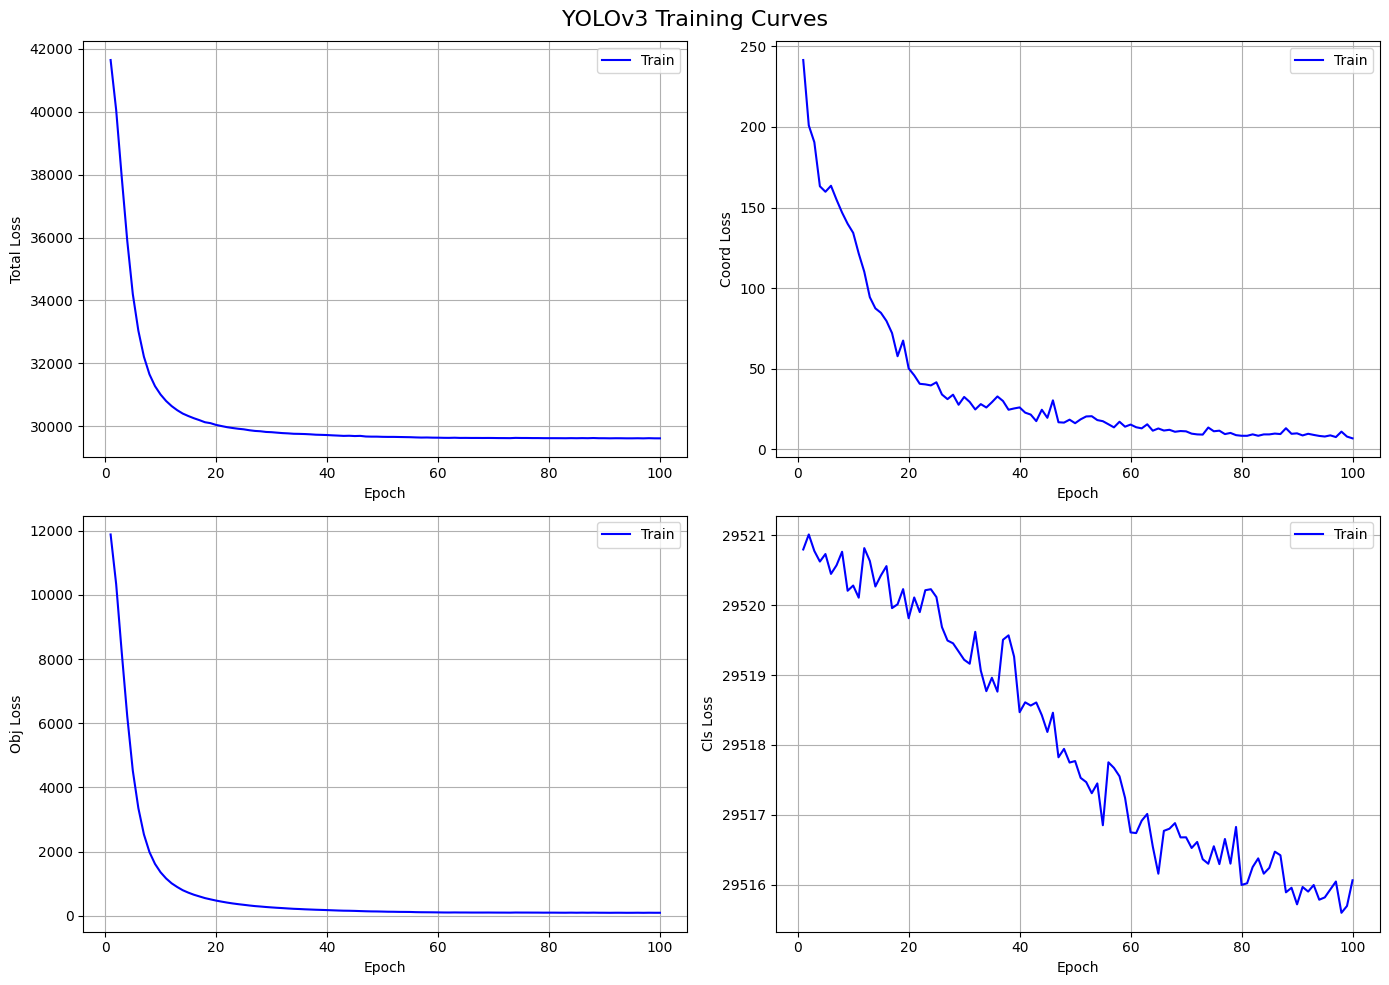

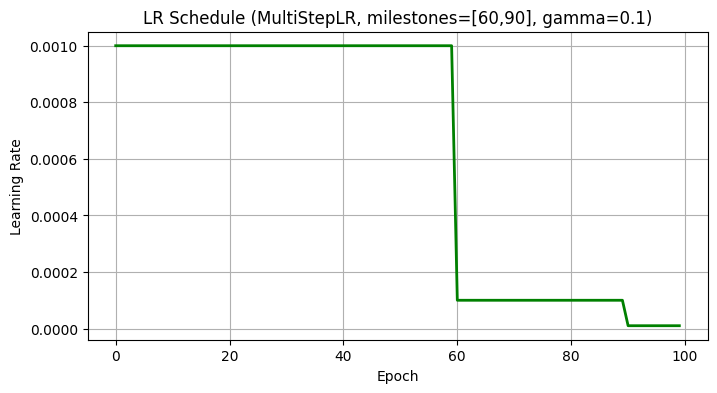


✅ 权重已保存: yolov3_little.pth

作业 2: 推理检测 + 可视化



C:\Users\13744\AppData\Local\Temp\ipykernel_40452\2179824942.py:271: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(final_pth, map_location=d

✅ 加载权重: yolov3_little.pth

📸 检测 18 张图片, 结果保存在 save_results/
  01.jpg: 检测到 0 个目标 → save_results/01.jpg
  02.jpg: 检测到 0 个目标 → save_results/02.jpg
  03.jpg: 检测到 0 个目标 → save_results/03.jpg
  04.jpg: 检测到 0 个目标 → save_results/04.jpg
  05.jpg: 检测到 0 个目标 → save_results/05.jpg
  06.jpg: 检测到 0 个目标 → save_results/06.jpg
  07.jpg: 检测到 0 个目标 → save_results/07.jpg
  08.jpg: 检测到 0 个目标 → save_results/08.jpg
  09.jpg: 检测到 0 个目标 → save_results/09.jpg
  10.jpg: 检测到 0 个目标 → save_results/10.jpg
  11.jpg: 检测到 0 个目标 → save_results/11.jpg
  12.jpg: 检测到 0 个目标 → save_results/12.jpg
  13.jpg: 检测到 0 个目标 → save_results/13.jpg
  14.jpg: 检测到 0 个目标 → save_results/14.jpg
  15.jpg: 检测到 0 个目标 → save_results/15.jpg
  16.jpg: 检测到 0 个目标 → save_results/16.jpg
  17.jpg: 检测到 0 个目标 → save_results/17.jpg
  18.jpg: 检测到 0 个目标 → save_results/18.jpg

📊 检测结果展示 (部分):


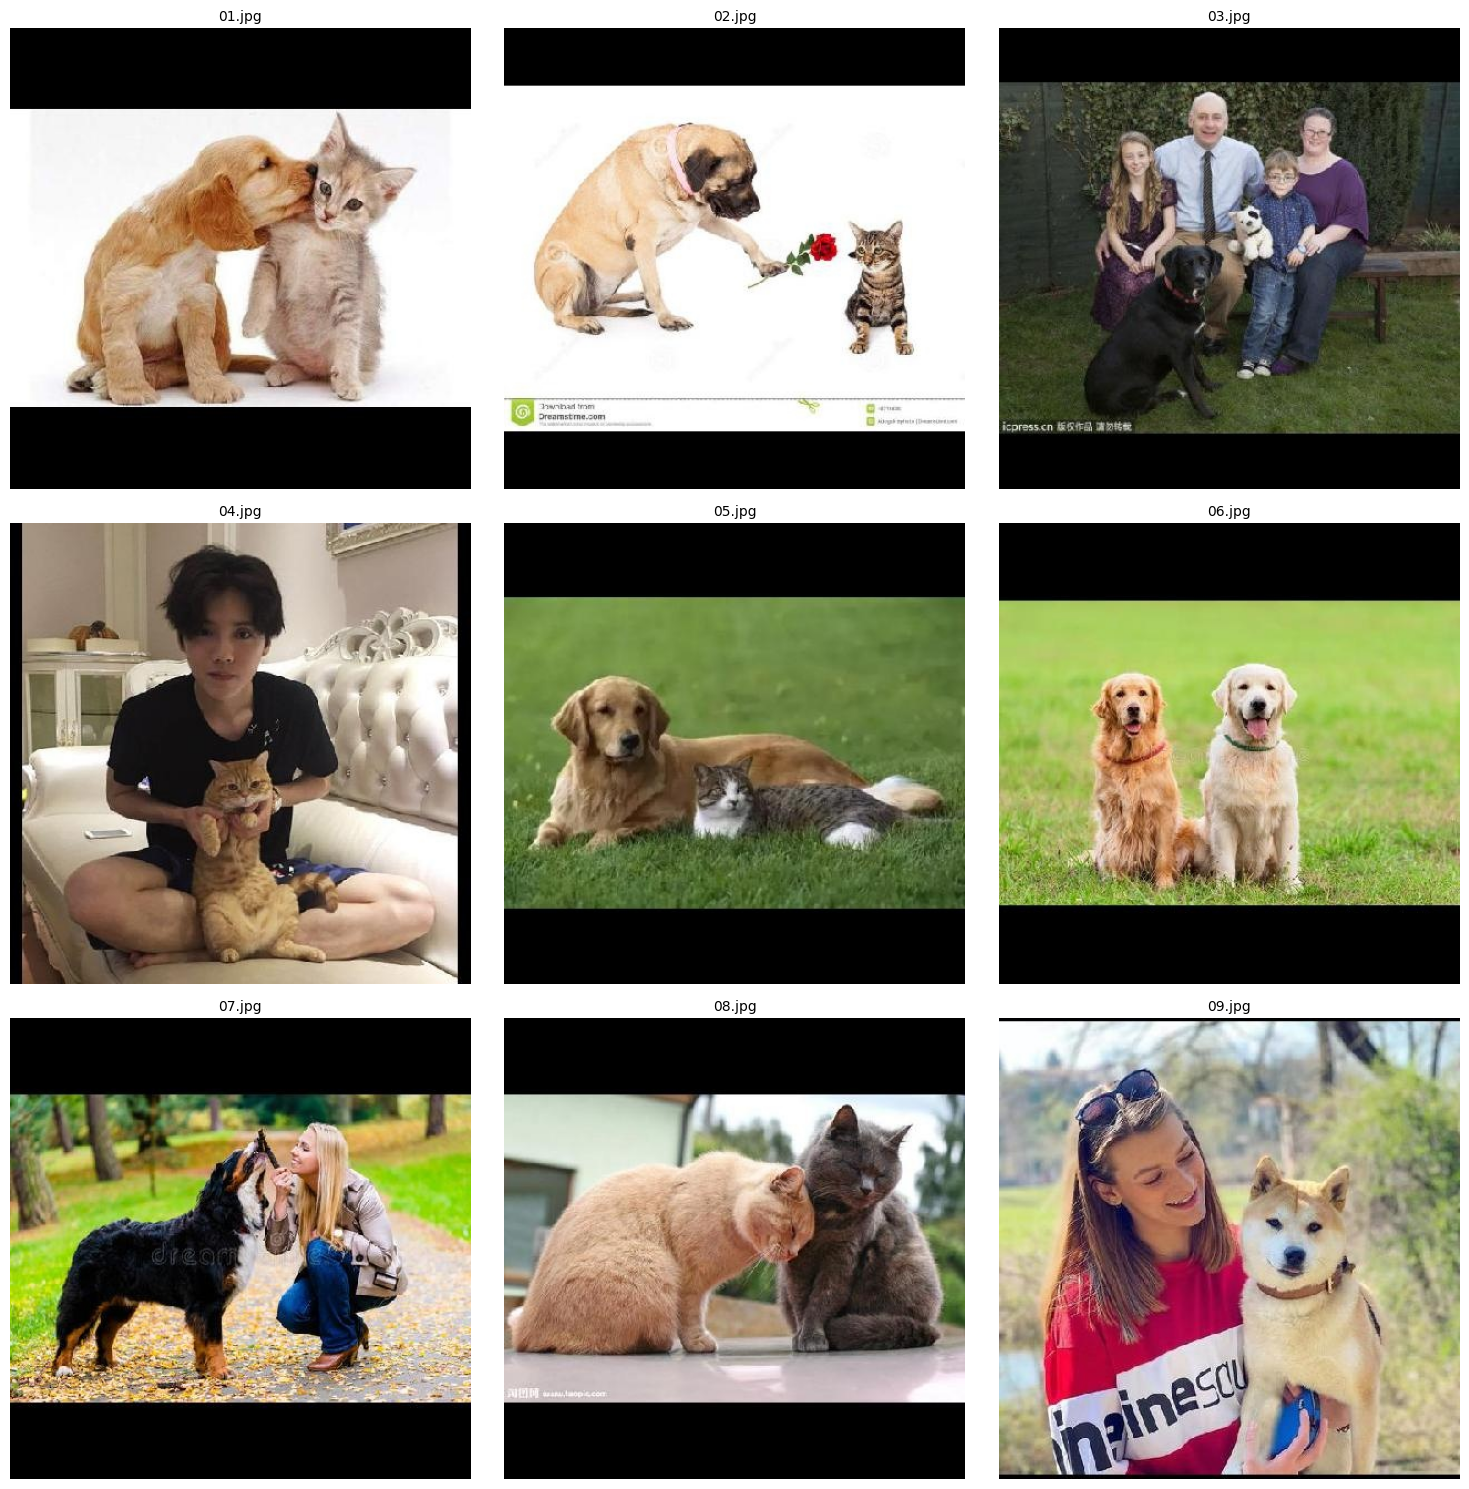


✅ 作业完成!
   ① 训练权重: yolov3_little.pth
   ② 推理结果: save_results/ 目录


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
#  作业 1: 训练 little_data → 生成 .pth 权重文件
# ═══════════════════════════════════════════════════════════════════════════

import sys, os, math
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from net_full import YOLOv3

# ── 数据集路径 ──
LITTLE_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'little_data')
LABEL_PATH = os.path.join(LITTLE_DIR, 'Parse_label.txt')
IMG_DIR = os.path.join(LITTLE_DIR, 'images')

# ── 自定义 Dataset ──
class LittleDataset(Dataset):
    """
    读取 little_data 的标注文件
    格式: images/xx.jpg cls cx cy w h    cls cx cy w h ...
    坐标是像素值, 需要归一化到 [0,1]
    4 类: 人=0, 猫=1, 狗=2, 马=3
    """
    def __init__(self, label_path, img_dir, img_size=416, num_classes=4):
        self.img_dir = img_dir
        self.img_size = img_size
        self.num_classes = num_classes
        with open(label_path, 'r', encoding='utf-8') as f:
            self.lines = [line.strip() for line in f.readlines() if line.strip()]

    def __len__(self):
        return len(self.lines)

    def __getitem__(self, idx):
        line = self.lines[idx]
        parts = line.replace('\t', ' ').split()
        img_name = parts[0]
        img_path = os.path.join(self.img_dir, os.path.basename(img_name))

        # 读图 → [3, 416, 416], 值域 [0,1]
        img = Image.open(img_path).convert('RGB')
        img = img.resize((self.img_size, self.img_size))
        img_tensor = torch.from_numpy(np.array(img)).float().permute(2, 0, 1) / 255.0

        # 解析标注框
        nums = np.array([float(x) for x in parts[1:]], dtype=np.float32)
        boxes = nums.reshape(-1, 5)  # [N, 5]

        # 编码为 3 个尺度的 label
        anchors = torch.tensor([
            [10,13],[16,30],[33,23],[30,61],[62,45],
            [59,119],[116,90],[156,198],[373,326]], dtype=torch.float32)
        anchor_groups = {13: anchors[6:9], 26: anchors[3:6], 52: anchors[0:3]}

        labels = {}
        for feat_size in [13, 26, 52]:
            labels[feat_size] = torch.zeros(feat_size, feat_size, 3, 5 + self.num_classes)

        for box in boxes:
            cls_id, cx, cy, bw, bh = box
            # 归一化
            cx_norm = cx / self.img_size
            cy_norm = cy / self.img_size
            bw_norm = bw / self.img_size
            bh_norm = bh / self.img_size

            for feat_size, anchors_fs in anchor_groups.items():
                stride = self.img_size // feat_size
                cx_idx = cx_norm * feat_size
                cy_idx = cy_norm * feat_size
                grid_x = int(math.floor(cx_idx))
                grid_y = int(math.floor(cy_idx))
                offset_x = cx_idx - grid_x
                offset_y = cy_idx - grid_y

                if grid_x < 0 or grid_x >= feat_size: continue
                if grid_y < 0 or grid_y >= feat_size: continue

                # 选最佳 anchor (宽高比匹配)
                best_ratio = -1
                best_a = 0
                for a_idx in range(3):
                    aw = anchors_fs[a_idx, 0].item()
                    ah = anchors_fs[a_idx, 1].item()
                    ratio = min(bw / aw, aw / bw) * min(bh / ah, ah / bh)
                    if ratio > best_ratio:
                        best_ratio = ratio
                        best_a = a_idx

                a_idx = best_a
                anchor_w = anchors_fs[a_idx, 0]
                anchor_h = anchors_fs[a_idx, 1]

                offset_w = float(np.log(bw / anchor_w.item() + 1e-8))
                offset_h = float(np.log(bh / anchor_h.item() + 1e-8))

                cls_onehot = torch.zeros(self.num_classes)
                cls_onehot[int(cls_id)] = 1.0

                labels[feat_size][grid_y, grid_x, a_idx] = \
                    torch.tensor([1.0, offset_x, offset_y, offset_w, offset_h] + cls_onehot.tolist(),
                                 dtype=torch.float32)

        return labels[13], labels[26], labels[52], img_tensor


# ── 训练 ──
print('='*50)
print('作业 1: 训练 little_data')
print('='*50)

dataset = LittleDataset(LABEL_PATH, IMG_DIR, img_size=416, num_classes=4)
loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

model = YOLOv3(nc=4)
print(f'模型参数量: {sum(p.numel() for p in model.parameters()):,}')

trainer = Train(
    model=model,
    train_loader=loader,
    lr=0.001,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    save_dir='checkpoints_little',
)

# 训练 100 epoch
history = trainer.train(epochs=100, print_interval=10, save_interval=50)

# 保存最终权重 .pth (纯模型权重, 不包含优化器等)
final_pth = 'yolov3_little.pth'
torch.save(model.state_dict(), final_pth)
print(f'\n✅ 权重已保存: {final_pth}')

# ═══════════════════════════════════════════════════════════════════════════
#  作业 2: 推理代码 + 注释 + 绘制检测结果
#  类别: ['人', '猫', '狗', '马']
# ═══════════════════════════════════════════════════════════════════════════

print('\n' + '='*50)
print('作业 2: 推理检测 + 可视化')
print('='*50 + '\n')

# ─────────────────────────────────────────────────────────────────────────
#  推理检测函数 (带详细注释)
# ─────────────────────────────────────────────────────────────────────────
def detect_one_image(model, img_path, conf_thresh=0.3, iou_thresh=0.45):
    """
    对单张图片执行 YOLOv3 检测

    参数:
        model:      YOLOv3 模型 (已加载权重)
        img_path:   图片文件路径
        conf_thresh: 置信度阈值, 低于此值的预测框被丢弃
        iou_thresh:  IoU 阈值, NMS 中高于此值且同类的框被抑制

    返回:
        dets:   [N, 6] 检测框 (x1, y1, x2, y2, conf, cls_id)
        img_pil: PIL Image 原图 (用于画框)
    """
    # 1. 读取图片, 转为 RGB
    img_pil = Image.open(img_path).convert('RGB')
    orig_w, orig_h = img_pil.size  # 原图尺寸, 用于后续坐标还原

    # 2. 预处理: resize → Tensor [1, 3, 416, 416]
    img_resized = img_pil.resize((416, 416))
    img_tensor = transforms.ToTensor()(img_resized)
    # ToTensor(): HWC → CHW + 除以 255 归一化到 [0,1]
    img_tensor = img_tensor.unsqueeze(0)  # [1, 3, 416, 416]

    # 3. 将图片送入 GPU (如果可用)
    device = next(model.parameters()).device
    img_tensor = img_tensor.to(device)

    # 4. 模型推理 (不计算梯度)
    model.eval()
    with torch.no_grad():
        # 前向传播 → 3 个尺度的原始输出
        # out_13:  [1, 3*(4+5), 13, 13]   stride=32, 检测小目标
        # out_26:  [1, 3*(4+5), 26, 26]   stride=16, 检测中目标
        # out_52:  [1, 3*(4+5), 52, 52]   stride=8,  检测大目标
        out_13, out_26, out_52 = model(img_tensor)

        # 5. 解码: 网络原始输出 → 边界框坐标 (x1,y1,x2,y2,conf,cls)
        #    decode_all 内部调用 decode_scale:
        #    - sigmoid(tx)+gx → 网格中心 x
        #    - sigmoid(ty)+gy → 网格中心 y
        #    - anchor_w * exp(tw) → 框宽
        #    - anchor_h * exp(th) → 框高
        #    - 最终置信度 = sigmoid(obj) × softmax(cls) 最大值
        from net_full import decode_all, post_process
        all_boxes = decode_all(out_13, out_26, out_52,
                               model.anchors, model.nc, 416)
        # all_boxes: [1, 10647, 6] — 合并了 3 个尺度的全部候选框

        # 6. NMS (非极大值抑制): 去除重复检测同目标的冗余框
        #    每张图独立做 NMS, 只保留每个目标上置信度最高的框
        dets = post_process(all_boxes, conf_thresh, iou_thresh)[0]
        # dets: [M, 6] — M 是最终保留的框数

    return dets.cpu(), img_pil


# ─────────────────────────────────────────────────────────────────────────
#  绘制检测结果 (带详细注释)
# ─────────────────────────────────────────────────────────────────────────
def draw_detections(img_pil, dets, class_names, conf_thresh=0.3):
    """
    在原图上绘制检测框

    参数:
        img_pil:     PIL Image 原图
        dets:        [N, 6] 检测框 (x1,y1,x2,y2,conf,cls_id)
        class_names: 类别名称列表 ['人', '猫', '狗', '马']
        conf_thresh: 显示阈值

    返回:
        OpenCV BGR 格式图像 (可直接用 cv2.imwrite 保存)
    """
    # PIL → OpenCV (RGB → BGR)
    img_np = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    orig_h, orig_w = img_np.shape[:2]

    # 每类分配一种颜色
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]

    for b in dets.numpy():
        # 解析每个框的 6 个值
        x1, y1, x2, y2, conf, cls_id = b

        # 过滤低置信度框
        if conf < conf_thresh:
            continue

        cls_id = int(cls_id)
        if cls_id >= len(class_names):
            continue

        # 坐标还原: 416×416 → 原图尺寸
        # 因为 decode_all 是在 416×416 上解码的
        x1 = int(x1 * orig_w / 416)
        y1 = int(y1 * orig_h / 416)
        x2 = int(x2 * orig_w / 416)
        y2 = int(y2 * orig_h / 416)

        # 绘制矩形框
        cv2.rectangle(img_np, (x1, y1), (x2, y2), colors[cls_id], 2)

        # 绘制标签文字
        label = f'{class_names[cls_id]}: {conf:.2f}'
        cv2.putText(img_np, label, (x1, max(y1-5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[cls_id], 2)

    return img_np


# ─────────────────────────────────────────────────────────────────────────
#  加载训练好的权重, 执行检测
# ─────────────────────────────────────────────────────────────────────────

CLASS_NAMES = ['人', '猫', '狗', '马']

# 1. 重新创建模型 & 加载训练好的权重
model = YOLOv3(nc=4)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.load_state_dict(torch.load(final_pth, map_location=device))
model.to(device)
print(f'✅ 加载权重: {final_pth}')

# 2. 遍历 little_data 中所有图片进行检测
img_files = sorted([f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')])
print(f'\n📸 检测 {len(img_files)} 张图片, 结果保存在 save_results/')
os.makedirs('save_results', exist_ok=True)

for img_name in img_files:
    img_path = os.path.join(IMG_DIR, img_name)

    # 推理
    dets, img_pil = detect_one_image(
        model, img_path, conf_thresh=0.3, iou_thresh=0.45)

    # 画框
    result_img = draw_detections(img_pil, dets, CLASS_NAMES, conf_thresh=0.3)

    # 保存结果
    save_path = f'save_results/{img_name}'
    cv2.imwrite(save_path, result_img)
    print(f'  {img_name}: 检测到 {len(dets)} 个目标 → {save_path}')

# 3. 展示部分检测结果
print('\n📊 检测结果展示 (部分):')
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for i, ax in enumerate(axes.flat):
    if i >= min(9, len(img_files)):
        ax.axis('off')
        continue
    img_name = img_files[i]
    result_path = f'save_results/{img_name}'
    if os.path.exists(result_path):
        img_bgr = cv2.imread(result_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(img_name, fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

print('\n✅ 作业完成!')
print(f'   ① 训练权重: {final_pth}')
print(f'   ② 推理结果: save_results/ 目录')
